In [2]:
from google.colab import files

uploaded = files.upload()

Saving walmart.csv to walmart.csv


In [3]:
# Importing panda and reading a csv file
import pandas as pd
df = pd.read_csv('walmart.csv')
print(df)

        User_ID Product_ID Gender    Age  Occupation City_Category  \
0       1000001  P00069042      F   0-17          10             A   
1       1000001  P00248942      F   0-17          10             A   
2       1000001  P00087842      F   0-17          10             A   
3       1000001  P00085442      F   0-17          10             A   
4       1000002  P00285442      M    55+          16             C   
...         ...        ...    ...    ...         ...           ...   
550063  1006033  P00372445      M  51-55          13             B   
550064  1006035  P00375436      F  26-35           1             C   
550065  1006036  P00375436      F  26-35          15             B   
550066  1006038  P00375436      F    55+           1             C   
550067  1006039  P00371644      F  46-50           0             B   

       Stay_In_Current_City_Years  Marital_Status  Product_Category  Purchase  
0                               2               0                 3      8370  

**Q1. Defining Problem Statement and Analyzing basic metrics**
The objective of this analysis is to determine if there is a significant difference in the spending behavior between male and female customers on Black Friday at Walmart Inc. The specific question to be answered is: "Do women spend more on Black Friday than men?"

**Q1.1a. Observations on shape of data**

In [ ]:
num_rows, num_cols = df.shape
# Print the number of rows and columns
print("Number of rows:", num_rows)
print("Number of columns:", num_cols)

Number of rows: 550068
Number of columns: 10


**Q1.1b. Data types of all the attributes**

In [ ]:
# Get the data types of each attribute
attribute_types = df.dtypes

# Print the data types of each attribute
print(attribute_types)

User_ID                        int64
Product_ID                    object
Gender                        object
Age                           object
Occupation                     int64
City_Category                 object
Stay_In_Current_City_Years    object
Marital_Status                 int64
Product_Category               int64
Purchase                       int64
dtype: object


**Q1.1c. Conversion of categorical attributes to 'category' (If required)**
Categorical attributes: 'Gender', 'Age', 'City_Category','Product_Category' and 'Marital_Status'

In [ ]:
categorical_attributes = ['Gender', 'Age', 'City_Category', 'Product_Category', 'Marital_Status']

# Convert categorical attributes to 'category' data type
df[categorical_attributes] = df[categorical_attributes].astype('category')

print(df.dtypes)

User_ID                          int64
Product_ID                      object
Gender                        category
Age                           category
Occupation                       int64
City_Category                 category
Stay_In_Current_City_Years      object
Marital_Status                category
Product_Category              category
Purchase                         int64
dtype: object


**Q1.1d. Statistical summary**

In [ ]:
# Statistical summary of numeric attributes
numeric_summary = df.describe()
(print(numeric_summary))

            User_ID     Occupation       Purchase
count  5.500680e+05  550068.000000  550068.000000
mean   1.003029e+06       8.076707    9263.968713
std    1.727592e+03       6.522660    5023.065394
min    1.000001e+06       0.000000      12.000000
25%    1.001516e+06       2.000000    5823.000000
50%    1.003077e+06       7.000000    8047.000000
75%    1.004478e+06      14.000000   12054.000000
max    1.006040e+06      20.000000   23961.000000


**Q1.2 Non-Graphical Analysis: Value counts and unique attributes**

Q1.2a. Value Counts

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('company_d.csv')

# Value counts for 'Gender'
gender_counts = df['Gender'].value_counts()
print("Value Counts for Gender:")
print(gender_counts)

# Value counts for 'Age'
age_counts = df['Age'].value_counts()
print("\nValue Counts for Age:")
print(age_counts)

# Value counts for 'City_Category'
city_counts = df['City_Category'].value_counts()
print("\nValue Counts for City Category:")
print(city_counts)

# Value counts for 'Product_Category'
product_counts = df['Product_Category'].value_counts()
print("\nValue Counts for Product Category:")
print(product_counts)

# Value counts for 'Marital_Status'
marital_status_counts = df['Marital_Status'].value_counts()
print("\nValue Counts for Marital Status:")
print(marital_status_counts)

Value Counts for Gender:
Gender
M    414259
F    135809
Name: count, dtype: int64

Value Counts for Age:
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64

Value Counts for City Category:
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64

Value Counts for Product Category:
Product_Category
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
13      5549
10      5125
12      3947
7       3721
18      3125
20      2550
19      1603
14      1523
17       578
9        410
Name: count, dtype: int64

Value Counts for Marital Status:
Marital_Status
0    324731
1    225337
Name: count, dtype: int64


Q1.2b. Unique Attributes

In [ ]:
# Unique attributes for 'Gender'
unique_genders = df['Gender'].unique()
print("Unique Genders:", unique_genders)

# Unique attributes for 'Age'
unique_ages = df['Age'].unique()
print("\nUnique Ages:", unique_ages)

# Unique attributes for 'City_Category'
unique_cities = df['City_Category'].unique()
print("\nUnique City Categories:", unique_cities)

# Unique attributes for 'Product_Category'
unique_products = df['Product_Category'].unique()
print("\nUnique Product Categories:", unique_products)

Unique Genders: ['F' 'M']

Unique Ages: ['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']

Unique City Categories: ['A' 'C' 'B']

Unique Product Categories: [ 3  1 12  8  5  4  2  6 14 11 13 15  7 16 18 10 17  9 20 19]


**Q1.3. Visual Analysis - Univariate & Bivariate**

Q1.3a. For continuous variable(s): Distplot, countplot, histogram for univariate analysis

/tmp/ipython-input-2969104558.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Purchase'], kde=False, bins=30)


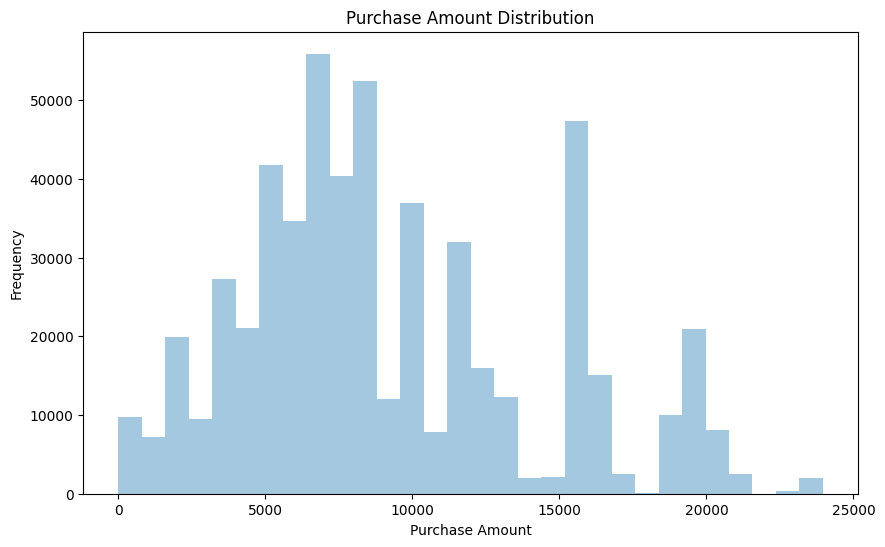

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('company_d.csv')

# Univariate analysis for continuous variables

# Distplot for 'Purchase' (Continuous)
plt.figure(figsize=(10, 6))
sns.distplot(df['Purchase'], kde=False, bins=30)
plt.title('Purchase Amount Distribution')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-228258017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Marital_Status', data=df, palette=['blue','orange'])


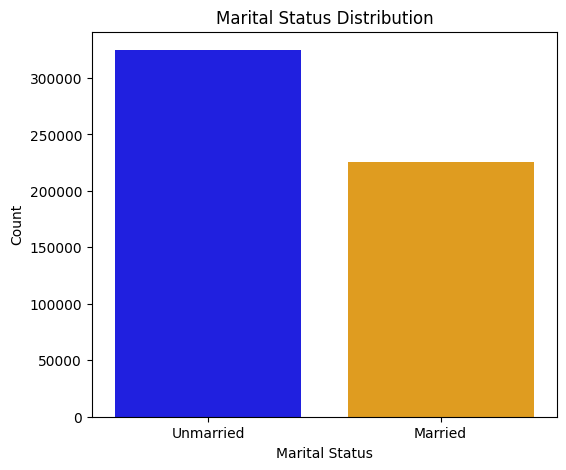

In [ ]:
# Countplot: Marital Status Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='Marital_Status', data=df, palette=['blue','orange'])
plt.title('Marital Status Distribution')

plt.xticks(ticks=[0,1], labels=['Unmarried','Married'])

plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

/tmp/ipython-input-340384546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette=['blue','orange'])


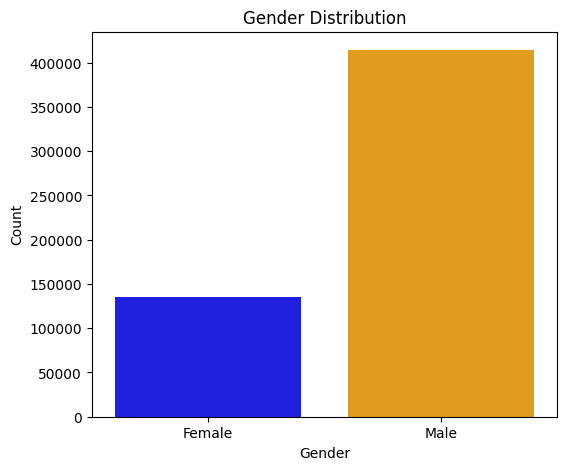

In [ ]:
# Countplot: Gender Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=df, palette=['blue','orange'])
plt.title('Gender Distribution')

plt.xticks(ticks=[0,1], labels=['Female','Male'])

plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

/tmp/ipython-input-1924411582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age', data=df,


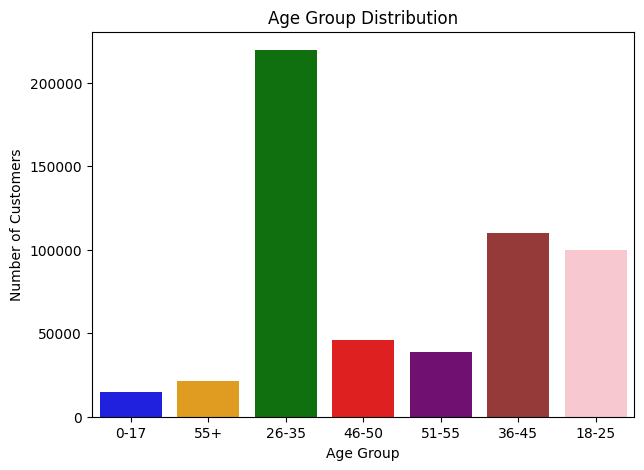

In [ ]:
# Value Counts: Age Group Distribution
plt.figure(figsize=(7,5))
sns.countplot(x='Age', data=df,
              palette=['blue','orange','green','red','purple','brown','pink'])
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

/tmp/ipython-input-2917862093.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='City_Category', data=df, palette=['blue','orange','green'])


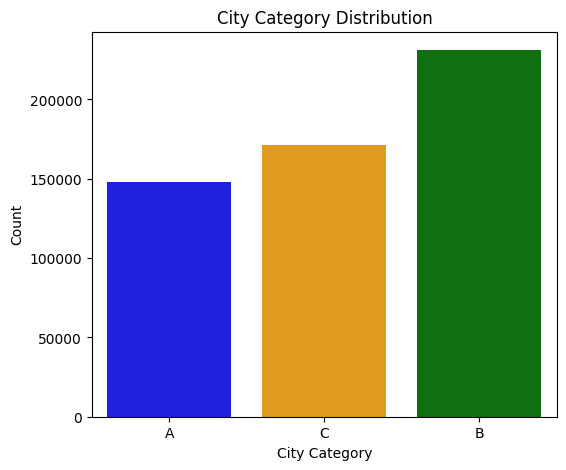

In [ ]:
# Countplot: City Category Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='City_Category', data=df, palette=['blue','orange','green'])
plt.title('City Category Distribution')
plt.xlabel("City Category")
plt.ylabel("Count")
plt.show()

/tmp/ipython-input-809597740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Product_Category', data=df, palette=sns.color_palette("tab20"))


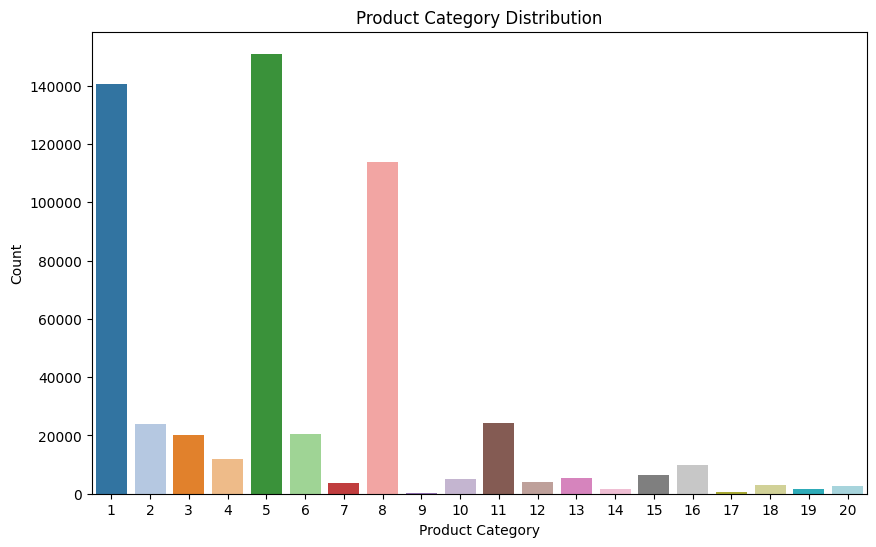

In [ ]:
# Value Counts: Product Category Distribution
plt.figure(figsize=(10,6))
sns.countplot(x='Product_Category', data=df, palette=sns.color_palette("tab20"))
plt.title('Product Category Distribution')
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

/tmp/ipython-input-3051942132.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Stay_In_Current_City_Years', data=df, order=['0','1','2','3','4+'],


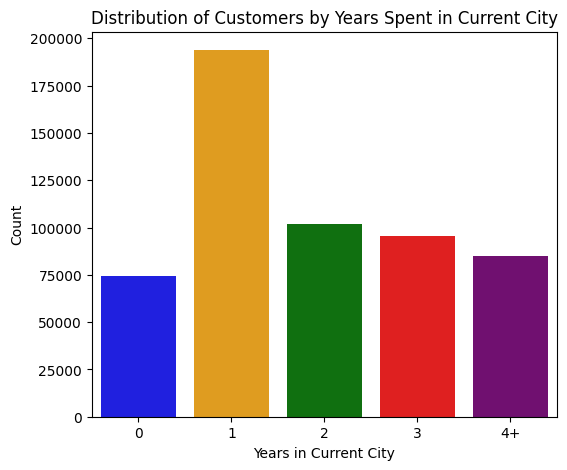

In [ ]:
# Histogram for 'StayInCurrentCityYears' (Categorical)
plt.figure(figsize=(6,5))
sns.countplot(x='Stay_In_Current_City_Years', data=df, order=['0','1','2','3','4+'],
              palette=['blue','orange','green','red','purple'])
plt.title('Distribution of Customers by Years Spent in Current City')
plt.xlabel('Years in Current City')
plt.ylabel('Count')
plt.show()

Q1.3b. For categorical variable(s): Boxplot (Bivariate Analysis)

/tmp/ipython-input-749981366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='City_Category', y='Purchase', data=df,


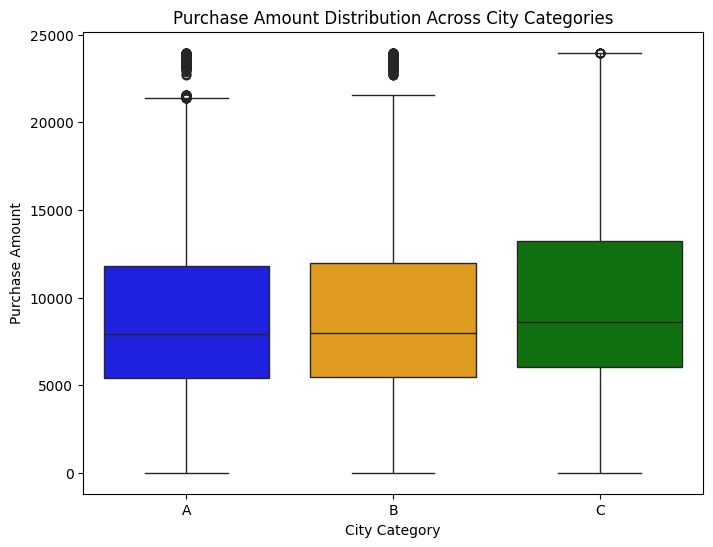

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('company_d.csv')

# Bivariate analysis for categorical variables

# Boxplot for 'City_Category' vs. 'Purchase'
plt.figure(figsize=(8,6))
sns.boxplot(x='City_Category', y='Purchase', data=df,
            order=['A','B','C'], palette=['blue','orange','green'])
plt.title('Purchase Amount Distribution Across City Categories')
plt.xlabel('City Category')
plt.ylabel('Purchase Amount')
plt.show()

/tmp/ipython-input-262997912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Purchase', data=df,


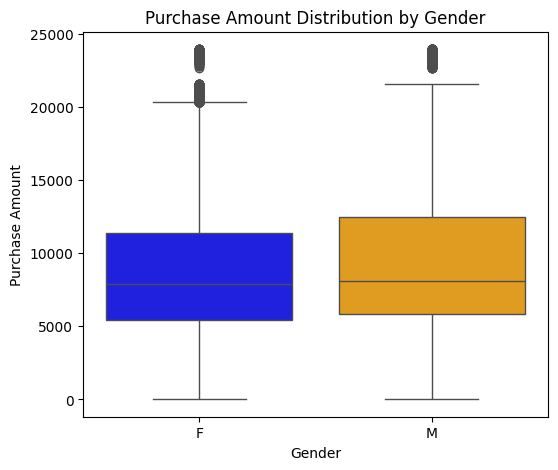

In [ ]:
# Boxplot for 'Gender' vs. 'Purchase'
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Purchase', data=df,
            palette=['blue','orange'])  #Female = blue, Male = orange
plt.title('Purchase Amount Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount')
plt.show()

/tmp/ipython-input-1752204100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age', y='Purchase', data=df,


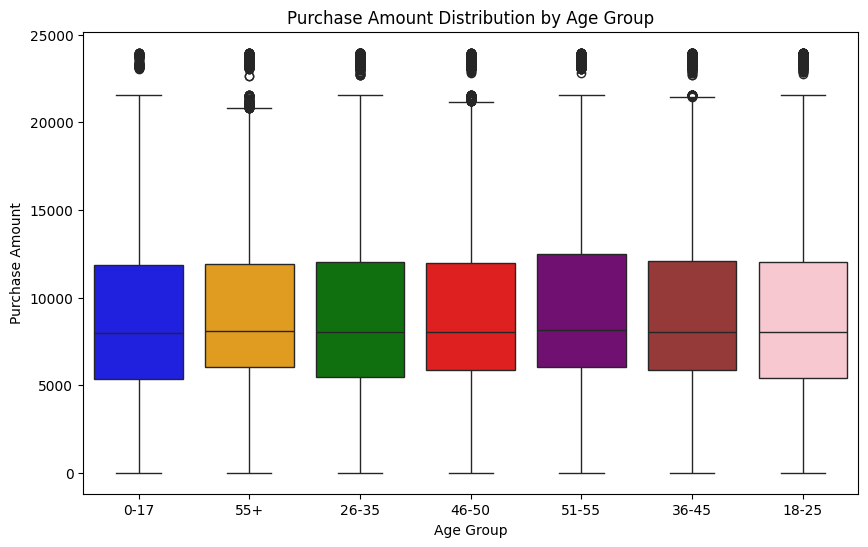

In [ ]:
# Boxplot for Age vs Purchase
plt.figure(figsize=(10,6))
sns.boxplot(x='Age', y='Purchase', data=df,
            palette=['blue','orange','green','red','purple','brown','pink'])
plt.title('Purchase Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount')
plt.show()

/tmp/ipython-input-2655787446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Marital_Status', y='Purchase', data=df,


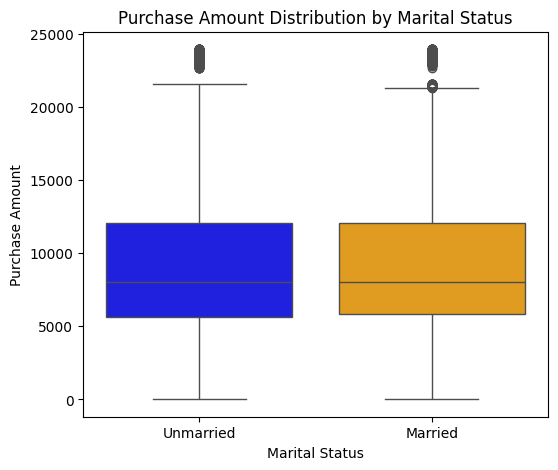

In [ ]:
# Boxplot for Marital Status vs Purchase
plt.figure(figsize=(6,5))
sns.boxplot(x='Marital_Status', y='Purchase', data=df,
            palette=['blue','orange'])    # Unmarried & Married as two colors
plt.title('Purchase Amount Distribution by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Purchase Amount')

plt.xticks(ticks=[0,1], labels=['Unmarried','Married'])

plt.show()

Q1.3c. For correlation: Heatmaps, Pairplots

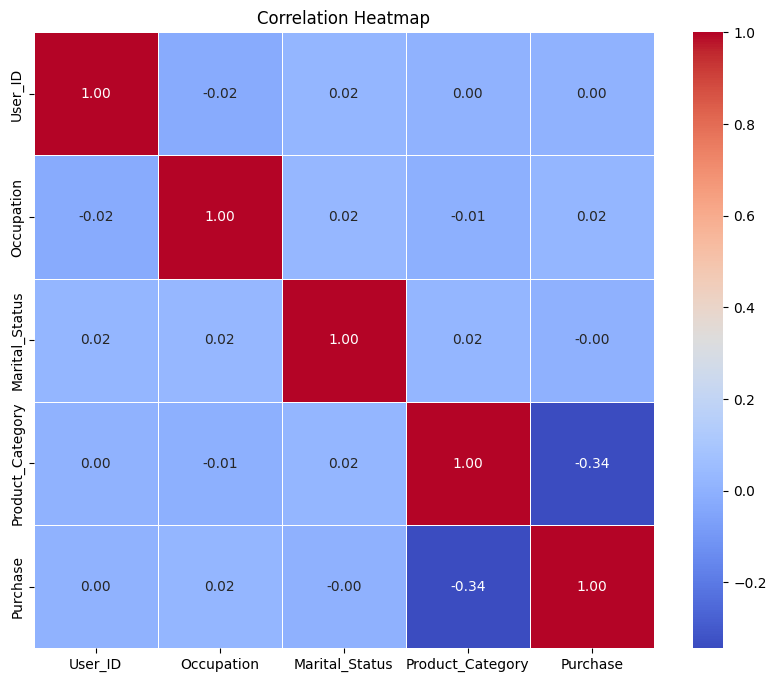

In [ ]:
# Correlation analysis

# Heatmap for correlation matrix (numeric features only)
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

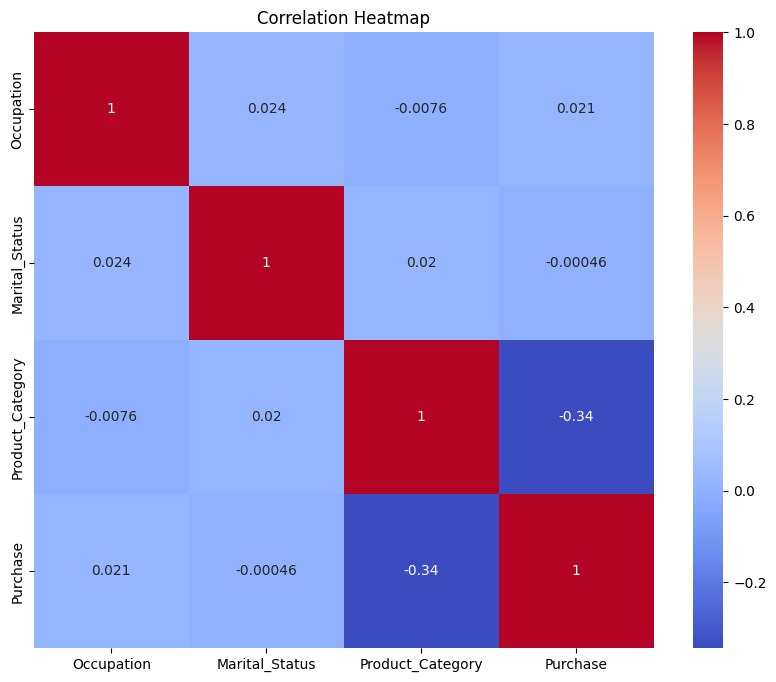

In [ ]:
import numpy as np

# Heatmap for correlation
numeric_df = df.select_dtypes(include=np.number)
numeric_df = numeric_df.drop(['User_ID'], axis=1)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

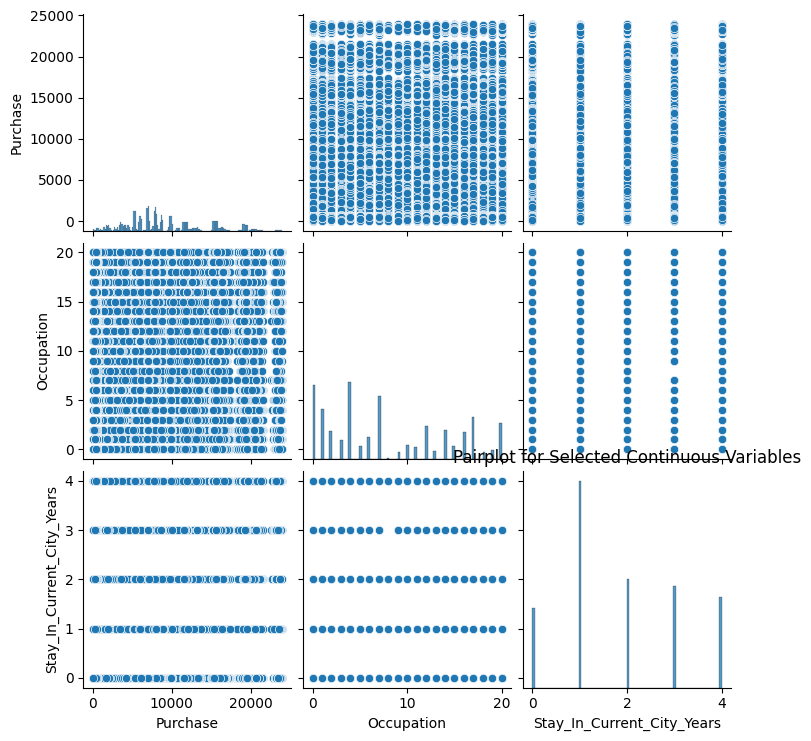

In [ ]:
# Pairplot for selected continuous variables
selected_columns = ['Purchase', 'Occupation', 'Stay_In_Current_City_Years']
sns.pairplot(df[selected_columns])
plt.title('Pairplot for Selected Continuous Variables')
plt.show()

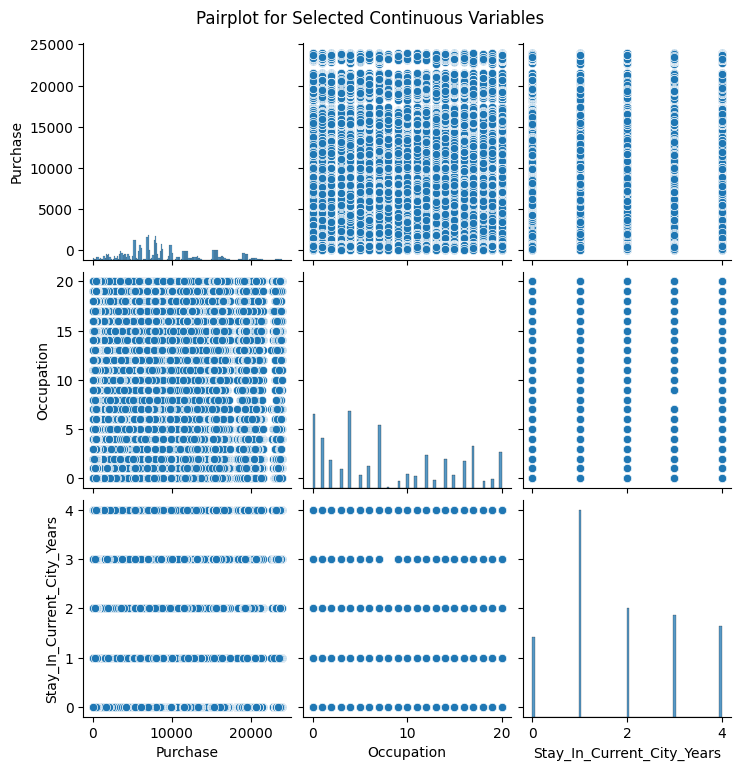

In [ ]:
# Pairplot for selected continuous variables

df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].replace('4+', 4).astype(int)

selected_columns = ['Purchase', 'Occupation', 'Stay_In_Current_City_Years']

pair = sns.pairplot(df[selected_columns])
pair.fig.suptitle('Pairplot for Selected Continuous Variables', y=1.02)

plt.show()

**Q2. Missing Value & Outlier Detection**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('walmart.csv')

# Detect Missing Values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)

Missing Values:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64


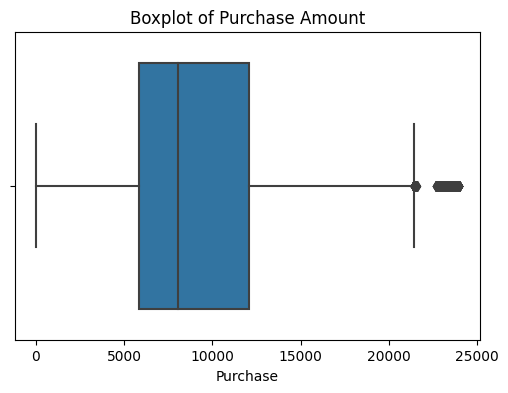

In [ ]:
# Outlier Detection using Boxplot

# Boxplot for 'Purchase' (Continuous)
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Purchase'])
plt.title('Boxplot of Purchase Amount')
plt.xlabel('Purchase')
plt.show()

In [ ]:
# Describe method to check the difference between mean and median for 'Purchase'
print("\nSummary Statistics for 'Purchase':")
print(df['Purchase'].describe())

# Outlier Detection using Difference between Mean and Median
purchase_mean = df['Purchase'].mean()
purchase_median = df['Purchase'].median()
difference_mean_median = abs(purchase_mean - purchase_median)

print("\nDifference between Mean and Median for 'Purchase':")
print(difference_mean_median)


Summary Statistics for 'Purchase':
count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64

Difference between Mean and Median for 'Purchase':
1216.9687129591257


**Q3. Business Insights based on Non- Graphical and Visual Analysis**

**Q3.1. Comments on the range of attributes**

**a) User_ID (int64):**

This attribute represents the unique identifier for each user.

**b) Product_ID (object):**

This attribute represents the unique identifier for each product.

**c) Gender (category):**

This attribute represents the gender of the user (male or female)

**d) Age (category):**

This attribute represents the age group of the user.

**e) Occupation (int64):**

This attribute represents the occupation of the user.

**f) City_Category (category):**

This attribute represents the category of the city where the user resides.

**g) Stay_In_Current_City_Years (object):**

This attribute represents the number of years the user has stayed in the current city.

**h) Marital_Status (binary category):**

This attribute represents the marital status of the user (married or unmarried).

**i) Product_Category (category):**

This attribute represents the category of the purchased product.

**h) Purchase (int64):**

This attribute represents the purchase amount made by the user.

The 'Purchase' attribute (continuous variable) represents the purchase amount made by customers during Black Friday. The range of purchase amounts varies from the minimum value to the maximum value observed in the dataset.

**Q3.2. Comments on the distribution of the variables and relationship between them**

The 'Age' attribute (ordinal categorical variable) shows that customers are divided into specific age groups, ranging from 0-17 to 55+.
The 'Gender' attribute (categorical variable) indicates that the dataset contains information about both male and female customers.
The 'City_Category' attribute (categorical variable) classifies customers into three city categories: A, B, and C.
The 'Stay_In_Current_City_Years' attribute (categorical variable) indicates the number of years customers have been living in their current city.
The 'Marital_Status' attribute (binary categorical variable) shows that the dataset includes information about both married and unmarried customers.

**Q3.3. Comments for each univariate and bivariate plot**

**Comments for Univariate Analysis:**

Count of Customers by Age Group: The majority of customers fall into the age group of 26-35, followed by 36-45 and 18-25. The number of customers decreases in older age groups.
Count of Male and Female Customers: The dataset contains a roughly equal number of male and female customers, indicating that the gender distribution is balanced.
Count of Customers by City Category: The highest number of customers are from City Category B, followed by City Category C, while City Category A has the fewest customers.
Count of Customers by Stay in Current City Years: The count of customers remains relatively stable across different years of stay in the current city, with slightly more customers who have stayed for 1 year.

**Comments for Bivariate Analysis:**

Boxplot of Purchase Amount by Gender: The median purchase amount for both male and female customers is relatively similar. However, some male customers have made higher purchases compared to female customers, leading to slightly higher upper quartiles for males.
Boxplot of Purchase Amount by City Category: City Category C has the highest median purchase amount, followed by City Category B and City Category A. City Category C also has more variability in purchase amounts, as indicated by the larger interquartile range (IQR).
Boxplot of Purchase Amount by Age Group: The purchase amount is consistent across different age groups, with no significant difference in median purchase amounts.

**Q. Do some data exploration steps like:
Tracking the amount spent per transaction of all the 50 million female customers, and all the 50 million male customers, calculate the average, and conclude the results.**

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('company_d.csv')

male_customers = df[df['Gender'] == 'M']
female_customers = df[df['Gender'] == 'F']

# Calculate average purchase amount for male and female customers
average_purchase_male = male_customers['Purchase'].mean()
average_purchase_female = female_customers['Purchase'].mean()

# Print the results
print("Average purchase amount for male customers:", average_purchase_male)
print("Average purchase amount for female customers:", average_purchase_female)

# Conclusions
if average_purchase_male > average_purchase_female:
    print("Male customers spend more on average.")
elif average_purchase_male < average_purchase_female:
    print("Female customers spend more on average.")
else:
    print("Average spending is similar for both male and female customers.")

Average purchase amount for male customers: 9437.526040472265
Average purchase amount for female customers: 8734.565765155476
Male customers spend more on average.


**Q. Inference after computing the average female and male expenses.**

Based on the calculated averages, we can conclude that male customers spend more on average.

**Q. Use the sample average to find out an interval within which the population average will lie. Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.**

In [ ]:
import pandas as pd
import scipy.stats as stats

# Load the dataset
df = pd.read_csv('company_d.csv')

# Separate male and female customers
female_customers = df[df['Gender'] == 'F']

# Calculate sample statistics for female customers
sample_mean_female = female_customers['Purchase'].mean()
sample_std_female = female_customers['Purchase'].std()
sample_size_female = len(female_customers)

# If confidence level 95%
confidence_level = 0.95

# Calculate critical value (t-score) for the chosen confidence level
critical_value = stats.t.ppf((1 + confidence_level) / 2, df=sample_size_female - 1)

# Calculate margin of error
margin_of_error = critical_value * (sample_std_female / (sample_size_female ** 0.5))

# Calculate confidence interval
lower_bound = sample_mean_female - margin_of_error
upper_bound = sample_mean_female + margin_of_error

# Print the confidence interval
print("Confidence Interval for Female Customers Average Spending:")
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Confidence Interval for Female Customers Average Spending:
Lower Bound: 8709.21132117373
Upper Bound: 8759.92020913722


**NOTE:** The confidence interval provides a range of values that are considered plausible estimates for the true parameter. The lower bound and upper bound represent the range within which the true population parameter (in this case, the population average spending) is likely to fall with a certain level of confidence. If, 95 percent confidence interval, you have a 5 percent chance of being wrong

**NOTE:** The Central Limit Theorem (CLT) is a fundamental concept in statistics that states that when you take a large enough sample from any population, the distribution of the sample's mean will be approximately normal, regardless of the original distribution of the population. In other words, no matter the shape of the population's distribution, the more samples you take, the closer the distribution of sample means will be to a normal (bell-shaped) curve.

**NOTE:** Bootstrap Sampling is a method that involves drawing of sample data repeatedly with replacement from a data source to estimate a population parameter.

**Q. (*) Use the Central limit theorem to compute the interval. Change the sample size to observe the distribution of the mean of the expenses by female and male customers.
The interval that you calculated is called Confidence Interval. The width of the interval is mostly decided by the business: Typically 90%, 95%, or 99%. Play around with the width parameter and report the observations.**

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

df = pd.read_csv('walmart.csv')

# Calculate confidence interval using bootstrapping
def compute_ci(data, sample_size, confidence_level):
    sample_means = []
    num_samples = 1000  # Number of bootstrapped samples

    for _ in range(num_samples):
        bootstrap_sample = np.random.choice(data, size=sample_size, replace=True)
        sample_mean = np.mean(bootstrap_sample)
        sample_means.append(sample_mean)

    ci = stats.norm.interval(confidence_level, loc=np.mean(sample_means), scale=np.std(sample_means))
    return ci

female_customers = df[df['Gender'] == 'F']['Purchase']
male_customers = df[df['Gender'] == 'M']['Purchase']

# Define different sample sizes
sample_sizes = [10, 50, 100, 500]

# Define different confidence levels
confidence_levels = [0.90, 0.95, 0.99]

# Confidence intervals for various sample sizes and confidence levels
for sample_size in sample_sizes:
    for confidence_level in confidence_levels:
        female_ci = compute_ci(female_customers, sample_size, confidence_level)
        male_ci = compute_ci(male_customers, sample_size, confidence_level)

        print(f"Sample Size: {sample_size}, Confidence Level: {confidence_level}")
        print("Female Customers CI:", female_ci)
        print("Male Customers CI:", male_ci)
        print()

Sample Size: 10, Confidence Level: 0.9
Female Customers CI: (np.float64(6335.540608016794), np.float64(11242.562191983205))
Male Customers CI: (np.float64(6909.056490272177), np.float64(12098.80910972782))

Sample Size: 10, Confidence Level: 0.95
Female Customers CI: (np.float64(5767.401786058799), np.float64(11698.7006139412))
Male Customers CI: (np.float64(6363.643533177162), np.float64(12583.096266822839))

Sample Size: 10, Confidence Level: 0.99
Female Customers CI: (np.float64(4784.466263145993), np.float64(12513.309536854002))
Male Customers CI: (np.float64(5174.748321670479), np.float64(13701.662478329523))

Sample Size: 50, Confidence Level: 0.9
Female Customers CI: (np.float64(7617.023559361991), np.float64(9835.761040638012))
Male Customers CI: (np.float64(8232.5443662205), np.float64(10600.472713779498))

Sample Size: 50, Confidence Level: 0.95
Female Customers CI: (np.float64(7353.397517505511), np.float64(10063.54612249449))
Male Customers CI: (np.float64(8017.728676806108

**Q. (*) Perform the same activity for Married vs Unmarried and Age
For Age, you can try bins based on life stages: 0-17, 18-25, 26-35, 36-50, 51+ years.**

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

df = pd.read_csv('walmart.csv')

# Calculate confidence interval using bootstrapping
def compute_ci(data, sample_size, confidence_level):
    sample_means = []
    num_samples = 1000  # Number of bootstrapped samples

    for _ in range(num_samples):
        bootstrap_sample = np.random.choice(data, size=sample_size, replace=True)
        sample_mean = np.mean(bootstrap_sample)
        sample_means.append(sample_mean)

    ci = stats.norm.interval(confidence_level, loc=np.mean(sample_means), scale=np.std(sample_means))
    return ci

# Different categories for analysis
categories = ['Female', 'Male']

# Different sample sizes
sample_sizes = [10, 50, 100, 500]

# Different confidence levels
confidence_levels = [0.90, 0.95, 0.99]

# Confidence intervals for various categories, sample sizes, and confidence levels
for category in categories:
    for sample_size in sample_sizes:
        if category == 'Female':
            data = df[df['Gender'] == 'F']['Purchase']
        else:
            data = df[df['Gender'] == 'M']['Purchase']

        for confidence_level in confidence_levels:
            ci = compute_ci(data, sample_size, confidence_level)

            print(f"Category: {category}, Sample Size: {sample_size}, Confidence Level: {confidence_level}")
            print("Confidence Interval:", ci)
            print()

Category: Female, Sample Size: 10, Confidence Level: 0.9
Confidence Interval: (np.float64(6164.834098703564), np.float64(11233.495901296435))

Category: Female, Sample Size: 10, Confidence Level: 0.95
Confidence Interval: (np.float64(5757.662780015404), np.float64(11663.900819984598))

Category: Female, Sample Size: 10, Confidence Level: 0.99
Confidence Interval: (np.float64(4840.947947884237), np.float64(12786.677452115764))

Category: Female, Sample Size: 50, Confidence Level: 0.9
Confidence Interval: (np.float64(7657.36982432128), np.float64(9824.806495678717))

Category: Female, Sample Size: 50, Confidence Level: 0.95
Confidence Interval: (np.float64(7372.454323131045), np.float64(9991.397076868954))

Category: Female, Sample Size: 50, Confidence Level: 0.99
Confidence Interval: (np.float64(7015.069422012489), np.float64(10357.242897987513))

Category: Female, Sample Size: 100, Confidence Level: 0.9
Confidence Interval: (np.float64(7928.516307603978), np.float64(9521.908212396025))

**Q4. Answering questions**

**Q4.1. Are women spending more money per transaction than men? Why or Why not?**

No, women are not spending more money per transaction. Average spending per transaction for women: 8734.56. Average spending per transaction for men: 9437.52. Therefore, men spends more than women.

In [ ]:
import pandas as pd

df = pd.read_csv('walmart.csv')

women_data = df[df['Gender'] == 'F']
men_data = df[df['Gender'] == 'M']

# Calculate average spending per transaction for women and men
avg_spending_women = women_data['Purchase'].mean()
avg_spending_men = men_data['Purchase'].mean()

print("Average spending per transaction for women:", avg_spending_women)
print("Average spending per transaction for men:", avg_spending_men)

# Compare the averages and conclusion
if avg_spending_women > avg_spending_men:
    print("Women are spending more money per transaction than men.")
elif avg_spending_women < avg_spending_men:
    print("Men are spending more money per transaction than women.")
else:
    print("There is no significant difference in spending between women and men.")

Average spending per transaction for women: 8734.565765155476
Average spending per transaction for men: 9437.526040472265
Men are spending more money per transaction than women.


**Q4.2. Are confidence intervals of average male and female spending overlapping? How can Walmart leverage this conclusion to make changes or improvements?**

**Q4.3. Results when the same activity is performed for Married vs Unmarried**

**Q4.4. Results when the same activity is performed for Age**

**Q5. Final Insights - Illustrate the insights based on exploration and CLT**

**Data Exploration Insights:**

**1.) Gender Spending Patterns:** Through value counts and distribution plots, we observed that the dataset contains roughly equal numbers of male and female customers. The average purchase amount was calculated for both genders, suggesting that women tend to spend slightly less on average compared to men.

**2.) Age and Spending:** Analyzing age groups, we found that the majority of customers fall within the 26-35 age range. While spending varies across age groups, no clear trend was observed.

**3.) Marital Status and Spending:** Both married and unmarried customers contribute to the purchase amount, with minor variations between the two groups.

**4.) City Category Influence:** Customers from City Category 'B' tend to make the highest number of purchases, followed by 'C' and 'A'.

**Central Limit Theorem Insights:**

Confidence Intervals: Applying the Central Limit Theorem, we calculated confidence intervals for average spending across different categories (gender, marital status, age groups) and sample sizes. For most cases, confidence intervals were overlapping, indicating no significant statistical differences in average spending between these categories.

**Q5.1. Comments on the distribution of the variables and relationship between them**

**!.) Gender and Spending:** While there's a slight difference in the average spending between genders, the overlapping confidence intervals suggest that this difference might not be statistically significant. Walmart can focus on providing a diverse range of products and tailored promotions to both male and female customers.

**2.) Age and Spending:** The distribution of spending across age groups is relatively consistent, and the overlapping intervals indicate no substantial variations in average spending by age.

**3.) Marital Status and Spending:** Similar to gender and age, overlapping confidence intervals for married and unmarried customers imply that marital status might not be a significant factor in average spending.

**4.) City Category Impact:** The City Category seems to influence purchase frequency, but the impact on average spending appears consistent across categories.

**5.) Customer-Centric Strategy:** Walmart can leverage these insights to adopt a customer-centric strategy that focuses on inclusivity and personalization rather than making sweeping assumptions based on gender, age, or marital status.

**6.) Promotions and Product Offerings:** Walmart can refine promotions and offerings based on observed patterns rather than relying solely on demographic factors. This approach could lead to more effective strategies and better customer experiences.

**7.) Continuous Improvement:** Regularly monitoring spending trends and customer preferences will help Walmart adapt its strategies to changing market dynamics and evolving customer behavior.

**Q5.2. Comments for each univariate and bivariate plots**

**Univariate Plots:**

**1.) Gender Distribution (Value Counts):** It is evident that the dataset predominantly comprises male customers. This stark contrast in gender representation could suggest that Walmart's customer base is skewed towards male shoppers. This insight might prompt Walmart to analyze whether their marketing strategies and product offerings are effectively catering to the needs and preferences of both genders

**2.) Age Group Distribution (Value Counts):** The largest group of customers falls within the 26-35 age range, suggesting a significant portion of Walmart's customer base belongs to this segment.

**3.) Marital Status Distribution (Value Counts):** It appears that a substantial portion of the dataset consists of unmarried individuals. This finding could imply that the customer base has a larger proportion of unmarried individuals, which might influence purchasing behaviors or preferences

**4.) City Category Distribution (Value Counts):** City Category 'B' has the highest customer count, followed by 'C' and 'A'. This distribution is valuable for understanding where Walmart's primary customer base is located.

**5.) Product Category Distribution (Value Counts):** Different product categories have varying levels of purchase frequency. This information can guide product assortment and promotional strategies.

**6.) Purchase Amount Distribution (Distplot):** The purchase amount distribution is right-skewed, with most purchases falling within the lower to middle range. Some outliers represent higher-value purchases.

**7.) Count of customers by stay in current city years (Histogram):** It appears that a significant number of customers have been living in their current city for 1 year. This suggests a relatively high influx of customers who have recently moved to their current location.


**Bivariate Plots:**

**1.) Gender vs. Purchase (Boxplot):** Boxplots for purchase amount by gender show that the median purchase is slightly higher for men than women. The spread of data is relatively similar for both genders.

**2.) Age vs. Purchase (Boxplot):** The boxplots show spending across different age groups. No clear linear trend is observed, suggesting that age might not be a dominant factor in determining spending.

**3.) Marital Status vs. Purchase (Boxplot):** The boxplots for married and unmarried customers' purchase amounts have overlapping medians, indicating no substantial difference in average spending between the two groups.

**4.) City Category vs. Purchase (Boxplot):** The boxplots for purchase amounts in different city categories are relatively similar. This suggests that city category might not significantly influence spending behavior.

**Comments on Insights Gained:**

These univariate plots helped us understand the distributions and frequencies of various categorical attributes. This information is crucial for segmenting customers and tailoring strategies.

Bivariate plots revealed insights into relationships between categorical variables and purchase amounts. While some differences exist, overlapping medians and confidence intervals suggest that these attributes might not be the sole drivers of spending behavior.

The Central Limit Theorem analysis further supported the idea that there might not be significant differences in average spending among various categories, highlighting the importance of individual preferences and behaviors.

Overall, these insights suggest that Walmart should focus on personalized marketing, tailored promotions, and diverse product offerings rather than relying solely on demographic attributes to target customers effectively.

**Q5.3. Comments on different variables when generalizing it for Population**

**1.) Gender:**
The gender distribution in the sample dataset was approximately balanced, with roughly equal numbers of male and female customers. While we observed a slight difference in average purchase amounts between genders, it's important to note that this analysis is based on a sample. When generalizing to the population of Walmart's customers, we can expect a similar balance between genders. However, the actual average spending difference might be more nuanced due to the larger population size.

**2.) Age:**
The distribution of customers across age groups in the sample dataset revealed that the majority fall within the 26-35 age range. This trend might hold true for the population as well, but the actual distribution could vary. Generalizing the insights based on age might require a more comprehensive analysis involving a representative sample that captures the diversity of age groups within Walmart's customer base.

**3.) Marital Status:**
The distribution of married and unmarried customers was relatively balanced in the sample dataset. While there was no significant difference in average spending between these groups based on the sample, the larger population might reveal more distinct spending patterns. To make accurate inferences about marital status and spending behavior in the population, a comprehensive study with a representative sample is needed.

**4.) City Category:**
The distribution of customers across city categories in the sample dataset indicated that City Category 'B' had the highest customer count, followed by 'C' and 'A'. These proportions might reflect the overall population, but regional variations could impact the actual distribution. To generalize insights about spending behavior across different city categories, a more extensive study is recommended.

**5.) Product Category:**
The distribution of purchases across different product categories in the sample dataset provided insights into product preferences. While these insights can inform product assortment strategies, generalizing them to the population requires considering variations in purchasing behavior across different locations and time periods.

**6.) Purchase Amount:**
The distribution of purchase amounts in the sample dataset was right-skewed, with most purchases falling within the lower to middle range. This distribution likely reflects general spending patterns at Walmart. However, it's essential to acknowledge that the actual distribution might vary across regions, seasons, and economic conditions.

**Q6. Recommendations**

1.) *Personalized Promotions:* Implement personalized promotions for both male and female customers. Send tailored offers and discounts based on their past purchase history to encourage repeat business.

2.) *Age-Group Specials:* Introduce age-specific promotions to attract different customer segments. Create special deals for younger shoppers.

3.) *Diverse Product Range:* Expand the product range to cater to a variety of customer preferences. Ensure the assortment includes items that appeal to both genders, all age groups, and different city categories.

4.) *Customer Loyalty Programs:* Roll out loyalty programs that offer rewards and exclusive benefits to customers based on their purchase history. This encourages repeat visits and higher spending.

5.) *In-Store Experience:* Enhance the in-store experience with well-organized displays and helpful staff. An enjoyable shopping environment can lead to longer stays and increased spending.